# Splitting X & Y

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fairlearn.datasets import fetch_diabetes_hospital

In [10]:
data = fetch_diabetes_hospital(as_frame=True)
X = data.data.copy()
X.drop(columns=["readmitted", "readmit_binary"], inplace=True)
y = data.target
X_ohe = pd.get_dummies(X)
race = X['race']

# Train/Test split + Train

In [ ]:
from fairlearn.metrics import MetricFrame
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

np.random.seed(42)  # set seed for consistent results

In [12]:
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(X_ohe, y, race, random_state=123)
classifier = DecisionTreeClassifier(min_samples_leaf=10, max_depth=4)
classifier.fit(X_train, y_train)
y_pred = (classifier.predict_proba(X_test)[:,1] >= 0.1)

# Evaluation

In [ ]:
from fairlearn.metrics import false_negative_rate, false_positive_rate, selection_rate, count
from sklearn.metrics import accuracy_score, balanced_accuracy_score


In [18]:
mf = MetricFrame(metrics=balanced_accuracy_score, y_true=y_test, y_pred=y_pred, sensitive_features=A_test)
mf.overall.item()
mf.by_group

race
AfricanAmerican    0.606692
Asian              0.586601
Caucasian          0.585538
Hispanic           0.647897
Other              0.624473
Unknown            0.577037
Name: balanced_accuracy_score, dtype: float64

In [15]:
mf = MetricFrame(metrics=false_negative_rate, y_true=y_test, y_pred=y_pred, sensitive_features=A_test)
mf.overall.item()
mf.by_group

race
AfricanAmerican    0.296089
Asian              0.500000
Caucasian          0.308555
Hispanic           0.307692
Other              0.333333
Unknown            0.420000
Name: false_negative_rate, dtype: float64

array([[<Axes: title={'center': 'accuracy'}, xlabel='race'>,
        <Axes: title={'center': 'false positive rate'}, xlabel='race'>,
        <Axes: title={'center': 'false negative rate'}, xlabel='race'>],
       [<Axes: title={'center': 'selection rate'}, xlabel='race'>,
        <Axes: title={'center': 'count'}, xlabel='race'>,
        <Axes: xlabel='race'>],
       [<Axes: xlabel='race'>, <Axes: xlabel='race'>,
        <Axes: xlabel='race'>]], dtype=object)

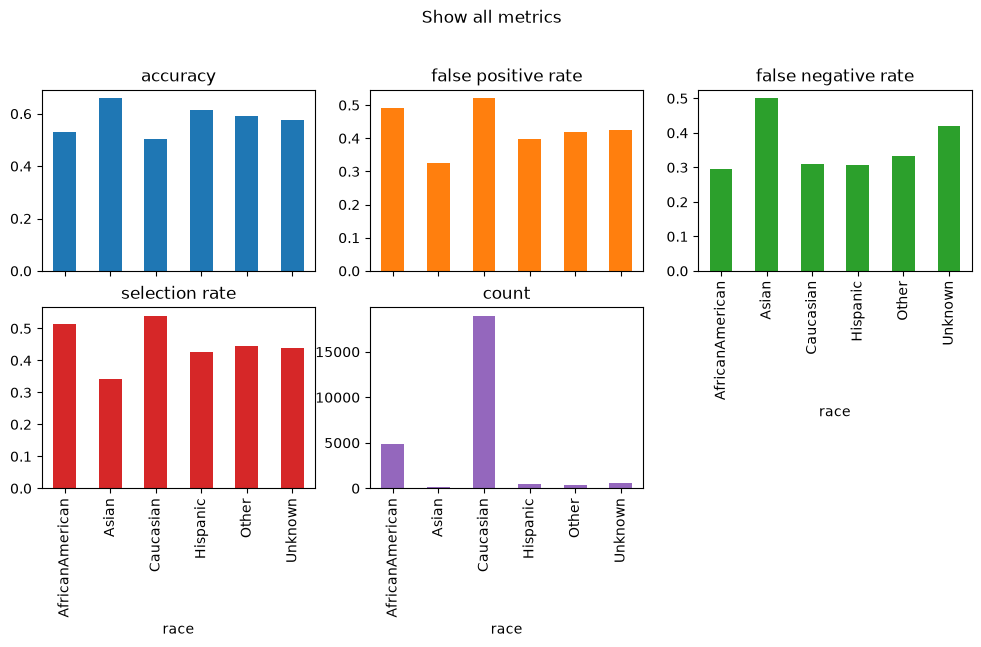

In [21]:
metrics = {
    "accuracy": accuracy_score,
    # "precision": zero_div_precision_score,
    "false positive rate": false_positive_rate,
    "false negative rate": false_negative_rate,
    "selection rate": selection_rate,
    "count": count,
}
metric_frame = MetricFrame(
    metrics=metrics, y_true=y_test, y_pred=y_pred, sensitive_features=A_test
)
metric_frame.by_group.plot.bar(
    subplots=True,
    layout=[3, 3],
    legend=False,
    figsize=[12, 8],
    title="Show all metrics",
)